In [ ]:
# Run this cell. If there are any issues, contact Miranda (toast.in.space)
# Make sure to upload this to jupyterlab or google collab to run, or use a venv to run on your own
import numpy as np
import tensorflow.keras as keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
IMAGE_DIMENSIONS = (x_train.shape[1], x_train.shape[2], x_train.shape[3])
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [3]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from keras.models import Sequential

In [14]:
def plot_curves(history, model_name):
    def plot_loss_curves(history, plot):
        plot.plot(history.history['loss'], label='Train Loss')
        plot.plot(history.history['val_loss'], label='Validation Loss')
        plot.title(f'{model_name}: Training & Validation Loss')
        plot.xlabel('Epoch')
        plot.ylabel('Mean Squared Error (Loss)')
        plot.legend()
        plot.grid(True)

    def plot_accuracy_curves(history, plot):
        plot.plot(history.history['accuracy'], label='Train Accuracy')
        plot.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plot.title(f'{model_name}: Training & Validation Accuracy')
        plot.xlabel('Epoch')
        plot.ylabel('Accuracy')
        plot.legend()
        plot.grid(True)
    
    plt.figure(figsize=(5,5))
    plot_loss_curves(history, plt)
    plt.show()
    plt.figure(figsize=(5,5))
    plot_accuracy_curves(history, plt)
    plt.show()

## Basic CNN
#### (The code below to the end is what gets copied and pasted)

In [4]:
basic_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    # The convolution layer detects specific features of an image in every section of the image
    Conv2D(32, 3, padding='same', activation='relu'),
    # Pooling reduces the dimensions of the feature maps from the convolution layer
    MaxPooling2D((2,2)),

    # The number of filters (the first parameter of Conv2D) expand to account for different combinations 
    # of features in the deeper parts of the model
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax') # Last dense layer has 10 units for the 10 types of labels
])

In [5]:
basic_cnn_model.compile(
    optimizer='adam',
    # Sparse categorical crossentropy is used when multiple labels are provided as 
    # integers, but not one-hot encoded
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
basic_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# This cell will take about a few minutes to run. If you have more layers or epochs, it could run longer
history_basic_cnn = basic_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4778 - loss: 1.6450 - val_accuracy: 0.5774 - val_loss: 1.1919
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6106 - loss: 1.1042 - val_accuracy: 0.6280 - val_loss: 1.0378
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.6625 - loss: 0.9609 - val_accuracy: 0.6432 - val_loss: 1.0405
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6968 - loss: 0.8628 - val_accuracy: 0.6662 - val_loss: 0.9776
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7271 - loss: 0.7830 - val_accuracy: 0.6884 - val_loss: 0.9560
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.7544 - loss: 0.7036 - val_accuracy: 0.6868 - val_loss: 0.9572
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7770 - loss: 0.6347 - val_accuracy: 0.6682 - val_loss: 1.0781
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.8002 -

In [12]:
basic_train_loss = history_basic_cnn.history['loss']
basic_train_accuracy = history_basic_cnn.history['accuracy']
basic_validation_loss = history_basic_cnn.history['val_loss']
basic_validation_accuracy = history_basic_cnn.history['val_accuracy']
basic_test_loss, basic_test_accuracy = basic_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6938 - loss: 1.1838


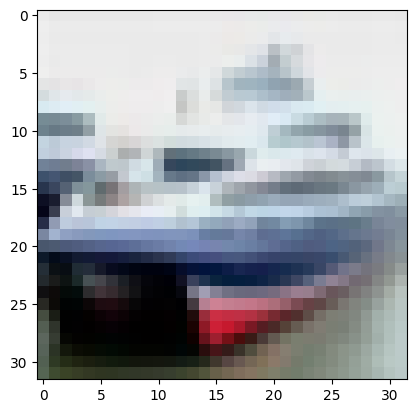

In [8]:
plt.imshow(x_test[1])

In [9]:
basic_cnn_predictions = basic_cnn_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [13]:
print(f"Basic CNN Model")
print(f"Final Train Accuracy: {basic_train_accuracy[len(basic_train_accuracy)-1]:.3f}, Final Train Loss: {basic_train_loss[len(basic_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {basic_validation_accuracy[len(basic_validation_accuracy)-1]:.3f}, Final Validation Loss: {basic_validation_loss[len(basic_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {basic_test_accuracy:.3f}, Test Loss: {basic_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(basic_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

Basic CNN Model
Final Train Accuracy: 0.834, Final Train Loss: 0.478
Final Validation Accuracy: 0.714, Final Validation Loss: 1.052
Test Accuracy: 0.694, Test Loss: 1.184
Example Prediction: ship, Actual = ship


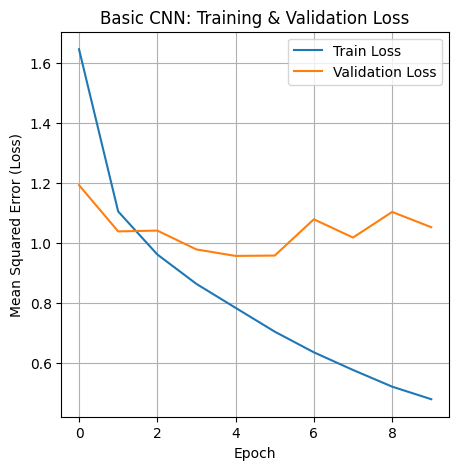

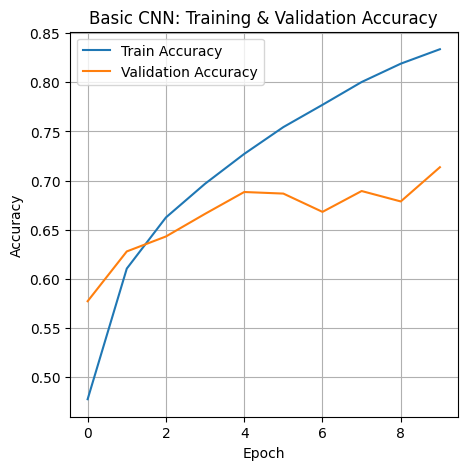

In [15]:
plot_curves(history_basic_cnn, "Basic CNN")